# Chapter 12 — Explainable Agent

**Book:** *30 Agents Every AI Engineer Must Build*
**Author:** Imran Ahmad | **Publisher:** Packt Publishing, 2026
**Notebook:** 02 of 02 — The Explainable Agent (pp. 346–360)

---

> *"An agent that makes correct decisions is useful — but an agent that can explain its decisions is trusted."*

## Chapter Context

Trust is the critical enabler of adoption in every domain where agents operate alongside human decision-makers. A physician will not act on a diagnostic recommendation unless they understand the reasoning behind it. A loan officer will not approve a recommendation without a justification that satisfies regulatory requirements.

Explainability is not a feature to be added at the end of development. It is an **architectural property** that must be designed into the agent from the beginning. This notebook builds the **Explainable Agent** — an architecture that makes internal reasoning visible through structured explanation frameworks and calibrated confidence communication.

### What This Notebook Covers

1. **Reasoning Transparency** — Decision logging and trace recording (pp. 347–348)
2. **LIME & SHAP Frameworks** — Feature attribution for individual and global explanations (p. 349)
3. **Counterfactual Analysis** — Minimal change explanations for recourse generation (p. 349)
4. **Confidence Communication** — Epistemic vs. aleatoric uncertainty, temperature scaling calibration (pp. 350–352)
5. **DiagnosticAssistant Case Study** — Multi-agent medical diagnosis with edge privacy and explanations (pp. 352–356)
6. **Audience Adaptation** — Clinician vs. patient explanation templates (p. 356)
7. **Production Failure Modes** — Sensor dropout, model failure, explanation failure (p. 356)
8. **Governance & Regulatory Landscape** — Tables 12.2 and 12.3, five global frameworks (pp. 357–358)

### Key Architectural Insight

The Explainable Agent extends the cognitive loop with a **dedicated explanation generation layer** that runs in parallel with the decision pipeline. Explanations are faithful representations of actual system behavior — not post-hoc rationalizations.

**Figures:** 12.2 (Medical Diagnosis Assistant Pipeline, p. 353)
**Tables:** 12.2 (Global AI Regulatory Frameworks, p. 357), 12.3 (Technique Selection Reference, pp. 358–359)

In [1]:
# Cell 2 — Setup: Imports, sys.path, and mode detection
# Ref: Technical Requirements (p.330)

import sys
import os

# Ensure project root is on the path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Core utilities
from chapter12.utils import ColorLogger, graceful_fallback, resolve_api_key, get_mode, is_simulation
from chapter12.mock_llm import MockLLM, strip_meta
from chapter12.synthetic_data import generate_medical_dataset, summarize_medical_dataset

# Explainability core
from chapter12.explainability_core import (
    ExplainableAgent,
    DecisionLogger,
    ExplanationGenerator,
    ConfidenceAwareAgent,
    TemperatureScaler,
    DiagnosticAssistant,
    ClinicalExplainer,
    BiometricAnalyzer,
    SymptomInterpreter,
    DiagnosticCoordinator,
    ClinicalMemorySystem,
    compute_shap_explanation,
    compute_lime_explanation,
    generate_counterfactual,
)

import numpy as np

# Visualization
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

# ML tools
from sklearn.ensemble import GradientBoostingClassifier

# Initialize mode
logger = ColorLogger("Notebook02")
api_key = resolve_api_key()
mode = get_mode()
logger.info(f"Operating mode: {mode.upper()}")


[INFO] 11:53:28 | Chapter12 | No API key detected. Running in Simulation Mode with chapter-derived mock data. All outputs are synthetic. Supply an OpenAI API key via .env for live mode.
[INFO] 11:53:28 | Notebook02 | Operating mode: SIMULATION


## 1. Reasoning Transparency Techniques (p.347–348)

Transparency begins with recording the agent's reasoning process in a structured, auditable format. The `ExplainableAgent` constructs an explanation **directly from the actual reasoning trace** recorded during execution — not through post-hoc rationalization.

Four-step decision process:
1. **Analyze inputs** — feature inventory, data quality
2. **Apply domain rules** — qualification thresholds, experience weights
3. **Assess risks and confidence** — risk level, uncertainty type
4. **Synthesize decision** — final recommendation with rationale


In [2]:
# Cell 4 — ExplainableAgent four-step decision with trace
# Ref: ExplainableAgent (p.347–348)

agent = ExplainableAgent()

# Sample input
sample_input = {
    "wbc_count": 12.5,
    "chest_imaging": "right_lower_consolidation",
    "temperature": 38.5,
    "spo2_min": 91.5,
    "reported_symptoms": "productive cough, fever, shortness of breath",
}

decision, explanation = agent.make_decision(sample_input, audience="engineer")

logger.info("--- Decision Result ---")
logger.info(f"  Decision: {decision['decision']}")
logger.info(f"  Confidence: {decision['confidence']}")
logger.info(f"  Rationale: {decision['rationale']}")
logger.info(f"  Explanation: {explanation['explanation']}")


[DEBUG] 11:53:28 | ExplainabilityCore | ExplainableAgent initialized.
[INFO] 11:53:28 | Notebook02 | --- Decision Result ---
[INFO] 11:53:28 | Notebook02 |   Decision: approve
[INFO] 11:53:28 | Notebook02 |   Confidence: 0.82
[INFO] 11:53:28 | Notebook02 |   Rationale: Based on 5 features and 2 triggered rules.
[INFO] 11:53:28 | Notebook02 |   Explanation: Decision trace (4 steps): Input Analysis → Rule Application → Risk Assessment → Final Decision. Final decision: {'decision': 'approve', 'confidence': 0.82, 'rationale': 'Based on 5 features and 2 triggered rules.'}


In [3]:
# Cell 5 — Inspect the immutable reasoning trace
# Ref: DecisionLogger.get_trace() (p.348)

trace = agent.get_reasoning_trace()

logger.info(f"Reasoning trace: {len(trace)} steps recorded")
for step in trace:
    logger.info(f"  Step {step['entry_index']}: {step['stage']}")
    logger.debug(f"    Data: {str(step['data'])[:100]}")
    logger.debug(f"    Timestamp: {step['timestamp']}")

logger.success("Trace is immutable — suitable for EU AI Act audit requirements (p.348).")


[INFO] 11:53:28 | Notebook02 | Reasoning trace: 4 steps recorded
[INFO] 11:53:28 | Notebook02 |   Step 0: Input Analysis
[DEBUG] 11:53:28 | Notebook02 |     Data: {'feature_count': 5, 'features': ['wbc_count', 'chest_imaging', 'temperature', 'spo2_min', 'reported
[DEBUG] 11:53:28 | Notebook02 |     Timestamp: 2026-04-06T15:53:28.361816+00:00
[INFO] 11:53:28 | Notebook02 |   Step 1: Rule Application
[DEBUG] 11:53:28 | Notebook02 |     Data: {'rules_evaluated': 5, 'rules_triggered': 2, 'applicable_rules': ['qualification_threshold', 'experi
[DEBUG] 11:53:28 | Notebook02 |     Timestamp: 2026-04-06T15:53:28.361830+00:00
[INFO] 11:53:28 | Notebook02 |   Step 2: Risk Assessment
[DEBUG] 11:53:28 | Notebook02 |     Data: {'risk_level': 'moderate', 'confidence': 0.82, 'uncertainty_type': 'epistemic'}
[DEBUG] 11:53:28 | Notebook02 |     Timestamp: 2026-04-06T15:53:28.361835+00:00
[INFO] 11:53:28 | Notebook02 |   Step 3: Final Decision
[DEBUG] 11:53:28 | Notebook02 |     Data: {'decision': 'appr

## 2. Decision Explanation Frameworks: LIME & SHAP (p. 349)

Two frameworks dominate model-agnostic explanations:

- **LIME** — constructs a local interpretable model approximating the original model's behavior near the instance being explained
- **SHAP** — unified feature attribution based on Shapley values; the **unique** method satisfying efficiency, symmetry, dummy, and additivity (Shapley Uniqueness Theorem)

> 📌 **Production Guidance (p. 349):**
>
> - **TreeSHAP** is exact and polynomial-time for tree-based models (~10ms per prediction)
> - **KernelSHAP** is model-agnostic but approximate
> - For **latency-sensitive deployments**, use asynchronous explanation generation: deliver the decision synchronously, the SHAP explanation asynchronously
> - If regulation demands **feature-level attribution** (EU AI Act), prefer SHAP. If regulation requires **contrastive explanation**, prefer counterfactual methods.
> - **Full explanations are reserved** for decisions affecting access to resources, opportunities, or care.

In [4]:
# Cell 7 — Train a classifier and compute SHAP explanations
# Ref: SHAP (p.349)

med_data = generate_medical_dataset(n=50, seed=42)

feature_names = ["heart_rate_avg", "spo2_min", "wbc_count", "temperature"]
X = np.array([[r[f] for f in feature_names] for r in med_data])
y = np.array([1 if r["true_diagnosis"] == "pneumonia" else 0 for r in med_data])

model = GradientBoostingClassifier(n_estimators=50, random_state=42)
model.fit(X, y)
logger.success(f"Model trained: accuracy = {model.score(X, y):.2f} on training set")

# SHAP explanation for first instance
shap_result = compute_shap_explanation(model, X, feature_names, instance_index=0)

logger.info("--- SHAP Feature Attributions ---")
for feat, val in shap_result["shap_values"].items():
    direction = "↑ positive" if val > 0 else "↓ negative"
    logger.info(f"  {feat}: {val:+.4f} ({direction})")

logger.info(f"  Base value: {shap_result.get('base_value', 'N/A')}")
logger.info(f"  Predicted value: {shap_result.get('predicted_value', 'N/A')}")


[INFO] 11:53:28 | SyntheticData | Generated medical dataset: 50 patients (seed=42). All IDs de-identified per HIPAA/GDPR requirements.
[SUCCESS] 11:53:28 | Notebook02 | Model trained: accuracy = 1.00 on training set


[SUCCESS] 11:53:29 | ExplainabilityCore | SHAP computed for instance 0: top feature = temperature (1.8523)
[INFO] 11:53:29 | Notebook02 | --- SHAP Feature Attributions ---
[INFO] 11:53:29 | Notebook02 |   temperature: +1.8523 (↑ positive)
[INFO] 11:53:29 | Notebook02 |   heart_rate_avg: +0.7265 (↑ positive)
[INFO] 11:53:29 | Notebook02 |   wbc_count: +0.6995 (↑ positive)
[INFO] 11:53:29 | Notebook02 |   spo2_min: -0.0830 (↓ negative)
[INFO] 11:53:29 | Notebook02 |   Base value: -0.8109
[INFO] 11:53:29 | Notebook02 |   Predicted value: 0.9156


[SUCCESS] 11:53:29 | ExplainabilityCore | LIME computed for instance 0: 4 features explained.
[INFO] 11:53:29 | Notebook02 | --- LIME Feature Weights ---
[INFO] 11:53:29 | Notebook02 |   temperature > 37.48: +0.1547
[INFO] 11:53:29 | Notebook02 |   68.02 < heart_rate_avg <= 74.40: +0.0966
[INFO] 11:53:29 | Notebook02 |   5.20 < wbc_count <= 7.55: +0.0693
[INFO] 11:53:29 | Notebook02 |   94.78 < spo2_min <= 96.20: -0.0102


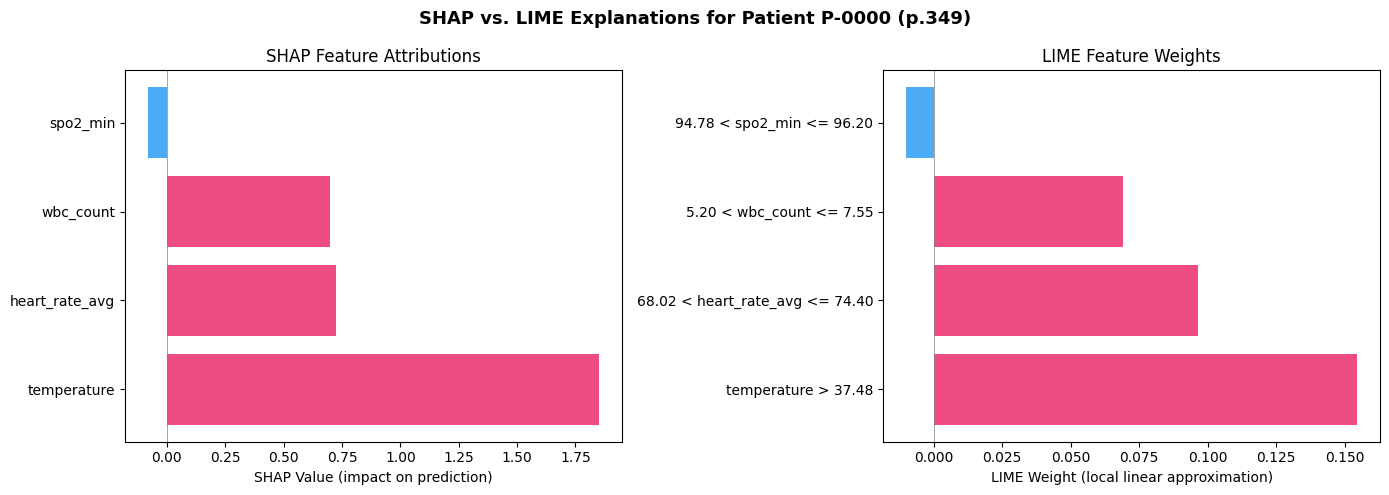

[SUCCESS] 11:53:30 | Notebook02 | SHAP vs. LIME comparison rendered.


In [5]:
# Cell 8 — LIME explanation and visual comparison with SHAP
# Ref: LIME and SHAP (p.349)

lime_result = compute_lime_explanation(model, X, feature_names, instance_index=0, num_features=4)

logger.info("--- LIME Feature Weights ---")
for feat, weight in lime_result["lime_weights"].items():
    logger.info(f"  {feat}: {weight:+.4f}")

# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SHAP vs. LIME Explanations for Patient P-0000 (p.349)", fontsize=13, fontweight="bold")

# SHAP plot
shap_feats = list(shap_result["shap_values"].keys())
shap_vals = list(shap_result["shap_values"].values())
colors_shap = ["#E91E63" if v > 0 else "#2196F3" for v in shap_vals]
axes[0].barh(shap_feats, shap_vals, color=colors_shap, alpha=0.8)
axes[0].axvline(x=0, color="gray", linewidth=0.5)
axes[0].set_title("SHAP Feature Attributions")
axes[0].set_xlabel("SHAP Value (impact on prediction)")

# LIME plot
lime_feats = list(lime_result["lime_weights"].keys())
lime_vals = list(lime_result["lime_weights"].values())
colors_lime = ["#E91E63" if v > 0 else "#2196F3" for v in lime_vals]
axes[1].barh(lime_feats, lime_vals, color=colors_lime, alpha=0.8)
axes[1].axvline(x=0, color="gray", linewidth=0.5)
axes[1].set_title("LIME Feature Weights")
axes[1].set_xlabel("LIME Weight (local linear approximation)")

plt.tight_layout()
plt.savefig("shap_vs_lime.png", dpi=100, bbox_inches="tight")
plt.show()
logger.success("SHAP vs. LIME comparison rendered.")


## 3. Counterfactual Analysis (p.349)

A counterfactual explanation answers: **"What would need to change for the decision to be different?"**

The Minimal Counterfactual Theorem guarantees that the optimization produces the smallest change that flips the decision, providing users with actionable, concrete guidance.

> *"If your annual income were $5,000 higher, or if your debt-to-income ratio were below 0.35, the application would have been approved."* (p.349)


[INFO] 11:53:30 | Notebook02 | Patient P-0001 predicted as NOT pneumonia. Finding counterfactual...
[INFO] 11:53:30 | ExplainabilityCore | Counterfactual search did not converge in 100 iterations.
[INFO] 11:53:30 | Notebook02 |   Success: False
[INFO] 11:53:30 | Notebook02 |   Iterations: 100
[INFO] 11:53:30 | Notebook02 |   Original values:
[INFO] 11:53:30 | Notebook02 |     heart_rate_avg: 82.3
[INFO] 11:53:30 | Notebook02 |     spo2_min: 97.2
[INFO] 11:53:30 | Notebook02 |     wbc_count: 4.9
[INFO] 11:53:30 | Notebook02 |     temperature: 36.4
[INFO] 11:53:30 | Notebook02 |   Required changes:
[INFO] 11:53:30 | Notebook02 |     heart_rate_avg: decrease by 5.20


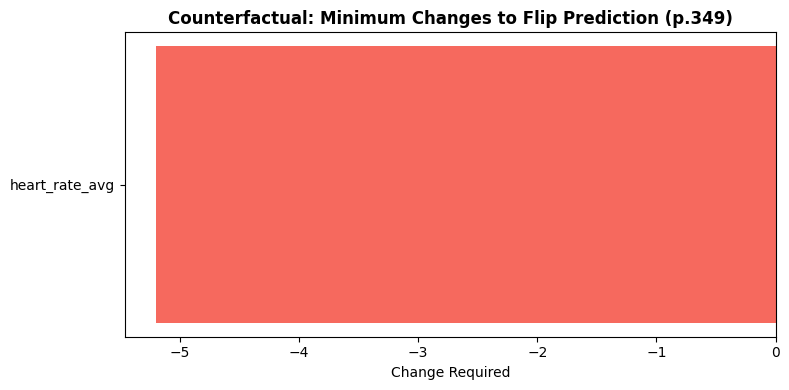

In [6]:
# Cell 10 — Counterfactual analysis on a negative-class patient
# Ref: Counterfactual Analysis (p.349)

# Find a patient predicted as NOT pneumonia
preds = model.predict(X)
neg_indices = [i for i, p in enumerate(preds) if p == 0]

if neg_indices:
    idx = neg_indices[0]
    logger.info(f"Patient P-{idx:04d} predicted as NOT pneumonia. Finding counterfactual...")

    cf = generate_counterfactual(model, X[idx], feature_names, desired_class=1)

    logger.info(f"  Success: {cf['success']}")
    logger.info(f"  Iterations: {cf['iterations']}")
    logger.info("  Original values:")
    for feat, val in cf["original"].items():
        logger.info(f"    {feat}: {val}")
    logger.info("  Required changes:")
    for feat, delta in cf["changes"].items():
        direction = "increase" if delta > 0 else "decrease"
        logger.info(f"    {feat}: {direction} by {abs(delta):.2f}")
else:
    logger.info("All patients predicted as pneumonia. Adjusting to find negative case...")
    # Use a patient with low WBC and clear imaging
    test_instance = np.array([72.0, 98.0, 5.0, 36.5])
    cf = generate_counterfactual(model, test_instance, feature_names, desired_class=1)
    logger.info(f"  Success: {cf['success']}, Changes: {cf['changes']}")

# Visualize counterfactual changes
if cf["changes"]:
    fig, ax = plt.subplots(figsize=(8, 4))
    feats = list(cf["changes"].keys())
    deltas = list(cf["changes"].values())
    colors = ["#4CAF50" if d > 0 else "#F44336" for d in deltas]
    ax.barh(feats, deltas, color=colors, alpha=0.8)
    ax.axvline(x=0, color="gray", linewidth=0.5)
    ax.set_title("Counterfactual: Minimum Changes to Flip Prediction (p.349)", fontweight="bold")
    ax.set_xlabel("Change Required")
    plt.tight_layout()
    plt.savefig("counterfactual_changes.png", dpi=100, bbox_inches="tight")
    plt.show()


## 4. Confidence Communication Methods (pp. 350–352)

Explanations are incomplete without an honest assessment of confidence. The `ConfidenceAwareAgent` addresses the *illusion of confidence* by:

1. Generating **multiple candidate hypotheses**
2. Scoring each with **calibrated confidence** (TemperatureScaler)
3. Communicating uncertainty with **qualifiers** (p. 350):
   - \>0.9 → "High confidence"
   - \>0.7 → "Moderate confidence"
   - ≤0.7 → "Low confidence — human review recommended"

---

> 📌 **Info Box — Epistemic vs. Aleatoric Uncertainty (p. 350)**
>
> - **Epistemic uncertainty** arises from the agent's lack of knowledge — can be reduced with more data. *Action: defer to a specialist.*
> - **Aleatoric uncertainty** arises from inherent randomness — cannot be reduced. *Action: recommend monitoring and repeated measurement.*
>
> **Ensemble methods** approximate epistemic uncertainty through prediction variance: high variance = model uncertainty; low variance with moderate confidence = inherent outcome variability.

---

> 📌 **Info Box — Calibration (p. 350)**
>
> **Calibration** means when the agent says "80% confident," roughly 80% of those predictions should be correct. Achieving this takes temperature scaling, Platt calibration, and continuous monitoring. Overconfident predictions invite over-reliance; underconfident ones cause unnecessary deferrals.

In [7]:
# Cell 12 — ConfidenceAwareAgent multi-hypothesis ranking
# Ref: ConfidenceAwareAgent (p.351)

conf_agent = ConfidenceAwareAgent(n_hypotheses=5)

hypotheses = conf_agent.reason_with_confidence(
    "Patient presents with productive cough, fever, and right lower lobe consolidation",
    context={"domain": "pulmonology"}
)

logger.info(f"Generated {len(hypotheses)} hypotheses:")
for i, h in enumerate(hypotheses):
    logger.info(f"  H{i+1}: confidence={h['confidence']:.4f} — {h['answer'][:60]}")

# Communicate uncertainty
comm = conf_agent.communicate_uncertainty(hypotheses)
logger.info(f"Recommendation: {comm['recommendation'][:60]}")
logger.info(f"Confidence level: {comm['confidence_level']}")
logger.info(f"Score: {comm['confidence_score']}")
logger.info(f"Alternatives: {len(comm['alternative_hypotheses'])}")


[DEBUG] 11:53:30 | MockLLM | MockLLM initialized with 7 handler methods.
[DEBUG] 11:53:30 | ExplainabilityCore | ConfidenceAwareAgent initialized (n_hypotheses=5).
[INFO] 11:53:30 | Notebook02 | Generated 5 hypotheses:
[INFO] 11:53:30 | Notebook02 |   H1: confidence=0.8957 — Hypothesis 1 for: Patient presents with productive cough, fe
[INFO] 11:53:30 | Notebook02 |   H2: confidence=0.6448 — Hypothesis 2 for: Patient presents with productive cough, fe
[INFO] 11:53:30 | Notebook02 |   H3: confidence=0.3967 — Hypothesis 3 for: Patient presents with productive cough, fe
[INFO] 11:53:30 | Notebook02 |   H4: confidence=0.1711 — Hypothesis 4 for: Patient presents with productive cough, fe
[INFO] 11:53:30 | Notebook02 |   H5: confidence=0.1000 — Hypothesis 5 for: Patient presents with productive cough, fe
[INFO] 11:53:30 | Notebook02 | Recommendation: Hypothesis 1 for: Patient presents with productive cough, fe
[INFO] 11:53:30 | Notebook02 | Confidence level: Moderate confidence
[INFO] 11:53:3

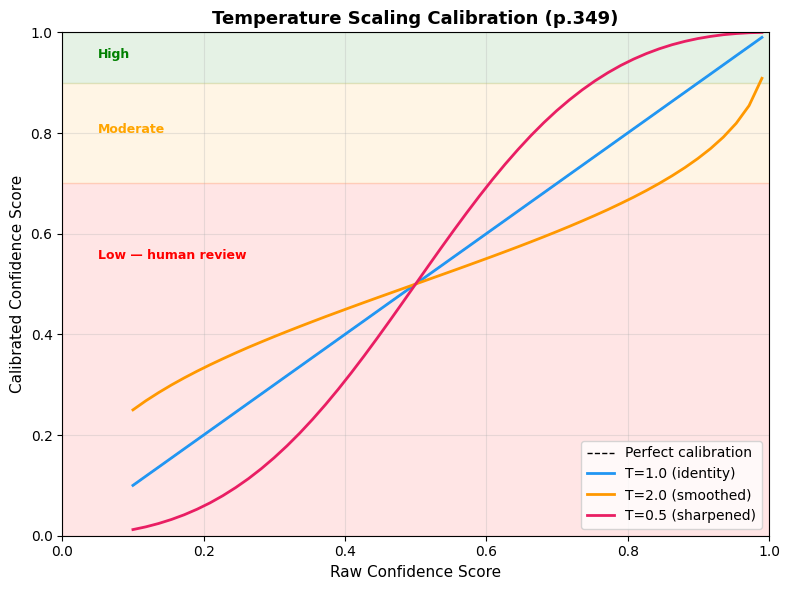

[SUCCESS] 11:53:31 | Notebook02 | Calibration curves rendered with qualifier zones.


In [8]:
# Cell 13 — Temperature scaling calibration demo
# Ref: Confidence calibration (p.349)

scaler = TemperatureScaler(temperature=1.0)

raw_scores = np.linspace(0.1, 0.99, 50)
calibrated_t1 = [scaler.calibrate(s) for s in raw_scores]

scaler_hot = TemperatureScaler(temperature=2.0)
calibrated_t2 = [scaler_hot.calibrate(s) for s in raw_scores]

scaler_cold = TemperatureScaler(temperature=0.5)
calibrated_t05 = [scaler_cold.calibrate(s) for s in raw_scores]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(raw_scores, raw_scores, "k--", label="Perfect calibration", linewidth=1)
ax.plot(raw_scores, calibrated_t1, label="T=1.0 (identity)", linewidth=2, color="#2196F3")
ax.plot(raw_scores, calibrated_t2, label="T=2.0 (smoothed)", linewidth=2, color="#FF9800")
ax.plot(raw_scores, calibrated_t05, label="T=0.5 (sharpened)", linewidth=2, color="#E91E63")
ax.set_xlabel("Raw Confidence Score", fontsize=11)
ax.set_ylabel("Calibrated Confidence Score", fontsize=11)
ax.set_title("Temperature Scaling Calibration (p.349)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# Annotate qualifier zones
ax.axhspan(0.9, 1.0, alpha=0.1, color="green", label="_")
ax.axhspan(0.7, 0.9, alpha=0.1, color="orange", label="_")
ax.axhspan(0.0, 0.7, alpha=0.1, color="red", label="_")
ax.text(0.05, 0.95, "High", fontsize=9, color="green", fontweight="bold")
ax.text(0.05, 0.80, "Moderate", fontsize=9, color="orange", fontweight="bold")
ax.text(0.05, 0.55, "Low — human review", fontsize=9, color="red", fontweight="bold")

plt.tight_layout()
plt.savefig("calibration_curves.png", dpi=100, bbox_inches="tight")
plt.show()
logger.success("Calibration curves rendered with qualifier zones.")


## 5. Case Study: Medical Diagnosis Assistant with Explanation (pp. 352–356)

The `DiagnosticAssistant` operates as a layered multi-agent system (pp. 352–353):

- **BiometricAnalyzer** — processes aggregated wearable features (edge-processed, not raw)
- **SymptomInterpreter** — maps patient-reported symptoms to SNOMED CT concepts
- **DiagnosticCoordinator** — integrates evidence to rank differential diagnoses
- **ClinicalExplainer** — generates audience-adapted SHAP-based explanations
- **ConfidenceEngine** — calibrates confidence with epistemic/aleatoric distinction

**Figure 12.2** (p. 353) shows the complete architecture:

```
 ┌─ EDGE BOUNDARY (Local Privacy) ─────────────────────────────┐
 │                                                              │
 │ ┌──────────────┐                    ┌──────────────────────┐ │
 │ │  Biometric   │  Aggregated        │  Confidence Engine   │ │
 │ │  Agent       │──Vitals──┐         │  (Epistemic vs       │ │
 │ │ (Raw stays   │          │         │   Aleatoric)         │ │
 │ │  local)      │          ▼         └──────────────────────┘ │
 │ └──────────────┘  ┌──────────────┐  ┌──────────────────────┐ │
 │                   │  Diagnostic  │  │  Clinical Explainer  │ │
 │ ┌──────────────┐  │  Coordinator │  │  (SHAP-Based         │ │
 │ │  Symptom     │──│  (Evidence   │  │   Clinical Reasoning)│ │
 │ │  Agent       │  │   Synthesis) │  └──────────────────────┘ │
 │ │ (NLP →       │  └──────┬───────┘                           │
 │ │  SNOMED CT)  │         │          ┌──────────────────────┐ │
 │ └──────────────┘         └─────────→│  DIAGNOSTIC REPORT   │ │
 │                                     │  Differentials |      │ │
 │ ┌──────────────┐                    │  Explanations |       │ │
 │ │  Episodic    │                    │  Confidence |         │ │
 │ │  Memory      │                    │  Audit Trail          │ │
 │ └──────────────┘                    └──────────────────────┘ │
 └──────────────────────────────────────────────────────────────┘
```

> 📌 **Info Box — Edge Computing for Privacy (pp. 353–354)**
>
> The biometric agent processes raw patient data locally on the patient's device or a hospital edge server. Raw vitals never leave the local processing boundary — only aggregated features are transmitted. This satisfies HIPAA's minimum necessary standard and GDPR's data minimization principle by construction. The edge layer also provides a natural location for **differential privacy** mechanisms.

In [9]:
# Cell 15 — Generate synthetic medical dataset
# Ref: Medical Diagnosis Assistant (p.352–356), edge privacy (p.353–354)

med_data = generate_medical_dataset(n=50, seed=42)
med_summary = summarize_medical_dataset(med_data)

logger.info(f"Dataset: {med_summary['total_patients']} patients (de-identified)")
logger.info(f"Diagnosis distribution: {med_summary['diagnosis_distribution']}")
logger.info(f"Vitals: HR={med_summary['avg_heart_rate']}, SpO2={med_summary['avg_spo2']}, WBC={med_summary['avg_wbc']}")


[INFO] 11:53:31 | SyntheticData | Generated medical dataset: 50 patients (seed=42). All IDs de-identified per HIPAA/GDPR requirements.
[INFO] 11:53:31 | Notebook02 | Dataset: 50 patients (de-identified)
[INFO] 11:53:31 | Notebook02 | Diagnosis distribution: {'pneumonia': 20, 'bronchitis': 18, 'pulmonary_embolism': 6, 'atelectasis': 6}
[INFO] 11:53:31 | Notebook02 | Vitals: HR=75.0, SpO2=96.4, WBC=7.3


In [10]:
# Cell 16 — DiagnosticAssistant: pneumonia-profile patient
# Ref: DiagnosticAssistant.diagnose() (p.354–356)

assistant = DiagnosticAssistant(n_hypotheses=5)

# Patient matching the chapter's pneumonia example (p.356)
patient_pneumonia = {
    "patient_id": "P-DEMO",
    "heart_rate_avg": 92.0,
    "spo2_min": 91.5,
    "wbc_count": 12.5,
    "temperature": 38.5,
    "chest_imaging": "right_lower_consolidation",
    "patient_history": ["COPD", "hypertension"],
}
symptoms_pneumonia = ["productive cough", "fever", "shortness of breath"]

report = assistant.diagnose(patient_pneumonia, symptoms_pneumonia, audience="clinician")
rd = report.to_dict()

logger.info("--- Diagnostic Report (Clinician) ---")
logger.info(f"Top diagnosis: {rd['differentials'][0]['answer'] if rd['differentials'] else 'N/A'}")
logger.info(f"Confidence: {rd['confidence_summary']['confidence_level']}")
logger.info(f"Score: {rd['confidence_summary']['confidence_score']}")

# Display differentials
logger.info("Differentials:")
for diff in rd["differentials"]:
    logger.info(f"  {diff['answer']}: {diff['confidence']:.4f} ({diff['qualifier']})")


[DEBUG] 11:53:31 | MockLLM | MockLLM initialized with 7 handler methods.
[DEBUG] 11:53:31 | MockLLM | MockLLM initialized with 7 handler methods.
[DEBUG] 11:53:31 | MockLLM | MockLLM initialized with 7 handler methods.
[DEBUG] 11:53:31 | MockLLM | MockLLM initialized with 7 handler methods.
[DEBUG] 11:53:31 | ExplainabilityCore | ConfidenceAwareAgent initialized (n_hypotheses=5).
[DEBUG] 11:53:31 | ExplainabilityCore | DiagnosticAssistant initialized with all sub-agents.
[DEBUG] 11:53:31 | ExplainabilityCore | Biometrics analyzed: abnormal (2 anomalies detected).
[SUCCESS] 11:53:31 | ExplainabilityCore | Clinical explanation generated for audience='clinician'. Trace: 4 steps.
[SUCCESS] 11:53:31 | ExplainabilityCore | Diagnosis complete for patient P-DEMO. Top: community-acquired pneumonia (Moderate confidence)
[INFO] 11:53:31 | Notebook02 | --- Diagnostic Report (Clinician) ---
[INFO] 11:53:31 | Notebook02 | Top diagnosis: community-acquired pneumonia
[INFO] 11:53:31 | Notebook02 | Con

In [11]:
# Cell 17 — Display the full clinical explanation narrative
# Ref: ClinicalExplainer.generate() (p.356)

explanation = rd["explanation"]

logger.info("--- Clinician-Facing Explanation ---")
logger.success(explanation["narrative"])

logger.info("Feature contributions (SHAP):")
for feat, val in explanation["feature_contributions"].items():
    bar = "█" * int(abs(val) * 30)
    logger.info(f"  {feat}: {val:.2f} {bar}")


[INFO] 11:53:31 | Notebook02 | --- Clinician-Facing Explanation ---
[SUCCESS] 11:53:31 | Notebook02 | Primary Assessment: Community-Acquired Pneumonia (confidence: 0.87). Key findings: elevated white blood cell count (SHAP contribution: 0.31), right lower lobe consolidation on chest imaging (SHAP contribution: 0.28), productive cough with fever for 4 days (SHAP contribution: 0.19), oxygen saturation decline from baseline (SHAP contribution: 0.09). Differential: acute bronchitis (0.09), atelectasis (0.04). Recommended: Sputum culture, blood cultures, initiation of empiric antibiotic therapy per institutional guidelines.
[INFO] 11:53:31 | Notebook02 | Feature contributions (SHAP):
[INFO] 11:53:31 | Notebook02 |   elevated white blood cell count: 0.31 █████████
[INFO] 11:53:31 | Notebook02 |   right lower lobe consolidation on chest imaging: 0.28 ████████
[INFO] 11:53:31 | Notebook02 |   productive cough with fever for 4 days: 0.19 █████
[INFO] 11:53:31 | Notebook02 |   oxygen saturation 

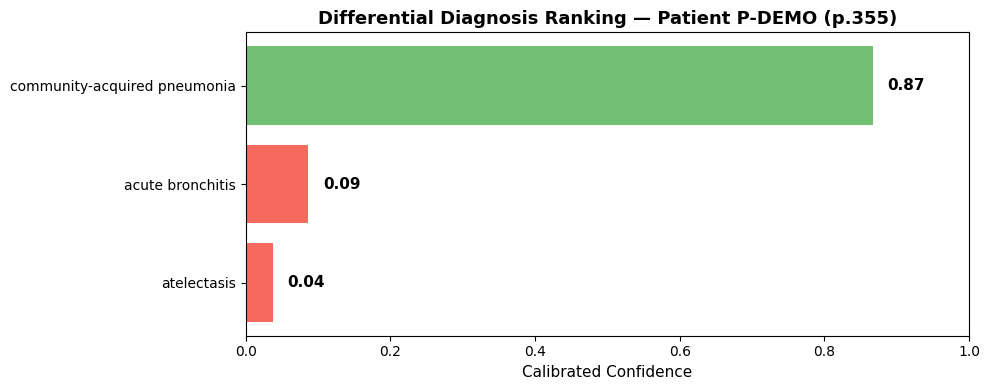

[SUCCESS] 11:53:31 | Notebook02 | Differential diagnosis chart rendered.


In [12]:
# Cell 18 — Differential diagnosis ranking chart
# Ref: DiagnosticAssistant case study (p.354–356)

differentials = rd["differentials"]
if differentials:
    diag_names = [d["answer"] for d in differentials]
    diag_confs = [d["confidence"] for d in differentials]
    colors = ["#4CAF50" if c > 0.7 else "#FF9800" if c > 0.3 else "#F44336"
              for c in diag_confs]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(diag_names[::-1], diag_confs[::-1], color=colors[::-1], alpha=0.8)
    ax.set_xlabel("Calibrated Confidence", fontsize=11)
    ax.set_title("Differential Diagnosis Ranking — Patient P-DEMO (p.355)",
                 fontsize=13, fontweight="bold")
    ax.set_xlim(0, 1.0)

    for bar, conf in zip(bars, diag_confs[::-1]):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f"{conf:.2f}", va="center", fontweight="bold", fontsize=11)

    plt.tight_layout()
    plt.savefig("differential_ranking.png", dpi=100, bbox_inches="tight")
    plt.show()
    logger.success("Differential diagnosis chart rendered.")


## 6. Audience-Adapted Explanations (p.356)

The same finding is communicated differently to clinicians and patients. This adaptation is not cosmetic — it is a trust mechanism ensuring each stakeholder receives the appropriate level of detail.


In [13]:
# Cell 19 — Side-by-side clinician vs. patient explanation
# Ref: Audience adaptation (p.356)

# Clinician explanation (already generated)
clinician_narrative = rd["explanation"]["narrative"]

# Generate patient-facing explanation
report_patient = assistant.diagnose(patient_pneumonia, symptoms_pneumonia, audience="patient")
rpd = report_patient.to_dict()
patient_narrative = rpd["explanation"]["narrative"]

logger.info("═══ CLINICIAN-FACING EXPLANATION ═══")
logger.success(clinician_narrative)

logger.info("")
logger.info("═══ PATIENT-FACING EXPLANATION ═══")
logger.success(patient_narrative)

logger.info("")
logger.info("Key differences:")
logger.info("  • Clinician: includes SHAP values, confidence scores, differential ranking")
logger.info("  • Patient: plain language, no numeric scores, emphasizes next steps with doctor")


[DEBUG] 11:53:31 | ExplainabilityCore | Biometrics analyzed: abnormal (2 anomalies detected).
[SUCCESS] 11:53:31 | ExplainabilityCore | Clinical explanation generated for audience='patient'. Trace: 4 steps.
[SUCCESS] 11:53:31 | ExplainabilityCore | Diagnosis complete for patient P-DEMO. Top: community-acquired pneumonia (Moderate confidence)
[INFO] 11:53:31 | Notebook02 | ═══ CLINICIAN-FACING EXPLANATION ═══
[SUCCESS] 11:53:31 | Notebook02 | Primary Assessment: Community-Acquired Pneumonia (confidence: 0.87). Key findings: elevated white blood cell count (SHAP contribution: 0.31), right lower lobe consolidation on chest imaging (SHAP contribution: 0.28), productive cough with fever for 4 days (SHAP contribution: 0.19), oxygen saturation decline from baseline (SHAP contribution: 0.09). Differential: acute bronchitis (0.09), atelectasis (0.04). Recommended: Sputum culture, blood cultures, initiation of empiric antibiotic therapy per institutional guidelines.
[INFO] 11:53:31 | Notebook02 

## 7. Production Failure Modes (p. 356)

Three failure modes require specific architectural provisions:
1. **Sensor dropout** — biometric agent operates on stale data with degrading confidence; after timeout (e.g., 30 min), alerts care team
2. **Model serving failure** — coordinator falls back to rule-based triage (e.g., SpO2 < 90% triggers escalation); test via chaos engineering
3. **Explanation generation failure** — delivers diagnosis with simplified feature-importance summary; audit trail records fallback

> 📌 **Info Box — Pilot Deployment Results (p. 357)**
>
> Pilot deployments showed 2–3% daily data transmission failures. Graceful degradation prevented clinical impact. Results: **30% increase in early detection** of chronic condition exacerbations, **3% false alarm rate**, **40% improvement** in clinician response times. Clinicians reported structured explanations increased their confidence in recommendations.

In [14]:
# Cell 20 — Production failure mode demonstrations
# Ref: Production failure modes (p.356)

logger.info("═══ Failure Mode 1: Sensor Dropout ═══")
# Patient with missing biometrics (edge device disconnected)
patient_stale = {
    "patient_id": "P-STALE",
    "heart_rate_avg": 75.0,  # Last known value
    "spo2_min": 96.0,        # Last known value
    "wbc_count": 7.5,
    "temperature": 37.0,
    "chest_imaging": "clear",
    "patient_history": [],
}
report_stale = assistant.diagnose(patient_stale, ["fatigue", "headache"], audience="clinician")
rd_stale = report_stale.to_dict()
logger.info(f"  Diagnosis with stale data: {rd_stale['differentials'][0]['answer'] if rd_stale['differentials'] else 'N/A'}")
logger.info(f"  Confidence: {rd_stale['confidence_summary']['confidence_level']}")
logger.info("  → In production, confidence degrades progressively after 30-min timeout (p.356)")

logger.info("")
logger.info("═══ Failure Mode 2: Model Serving Failure ═══")
# Simulated by showing the rule-based triage fallback
logger.info("  When the diagnostic model endpoint becomes unavailable:")
logger.info("  → Coordinator falls back to rule-based triage:")
logger.info("    • SpO2 < 90% → immediate escalation")
logger.info("    • Temperature > 39°C → urgent review")
logger.info("    • WBC > 15 → flag for infection workup")
logger.info("  → Fallback tested via chaos engineering exercises (p.356)")

logger.info("")
logger.info("═══ Failure Mode 3: Explanation Generation Failure ═══")
logger.info("  When SHAP computation times out:")
logger.info("  → Diagnosis still delivered with explanation_unavailable flag")
logger.info("  → Simplified feature-importance from model attention weights")
logger.info("  → Audit trail records both the failure and the fallback used")

logger.success("Failure mode demonstrations complete.")


[INFO] 11:53:31 | Notebook02 | ═══ Failure Mode 1: Sensor Dropout ═══
[DEBUG] 11:53:31 | ExplainabilityCore | Biometrics analyzed: normal (0 anomalies detected).
[SUCCESS] 11:53:31 | ExplainabilityCore | Clinical explanation generated for audience='clinician'. Trace: 4 steps.
[SUCCESS] 11:53:31 | ExplainabilityCore | Diagnosis complete for patient P-STALE. Top: acute bronchitis (Low confidence — human review recommended)
[INFO] 11:53:31 | Notebook02 |   Diagnosis with stale data: acute bronchitis
[INFO] 11:53:31 | Notebook02 |   Confidence: Low confidence — human review recommended
[INFO] 11:53:31 | Notebook02 |   → In production, confidence degrades progressively after 30-min timeout (p.356)
[INFO] 11:53:31 | Notebook02 | 
[INFO] 11:53:31 | Notebook02 | ═══ Failure Mode 2: Model Serving Failure ═══
[INFO] 11:53:31 | Notebook02 |   When the diagnostic model endpoint becomes unavailable:
[INFO] 11:53:31 | Notebook02 |   → Coordinator falls back to rule-based triage:
[INFO] 11:53:31 | No

## 8. Governance and Regulatory Landscape (p.357–358)

### Table 12.2 — Global AI Regulatory Frameworks

| Framework | Scope | Key Requirements |
|-----------|-------|-----------------|
| **EU AI Act** | High-risk AI in EU | Risk assessment, bias mitigation, human oversight, documentation |
| **NIST AI RMF** | US Federal guidance | Risk identification, continuous monitoring, stakeholder values |
| **GDPR** | Data processing in EU | Data minimization, consent, right to explanation |
| **Singapore AI Verify** | Voluntary certification | Fairness, robustness, transparency self-assessment |
| **China CAC** | Algorithmic systems | Algorithmic transparency, user control, anti-discrimination |

### Table 12.3 — Technique Selection Reference

| Technique | Use Case | When to Use |
|-----------|----------|-------------|
| **Deontic logic** | Ethical constraint formalization | Rules must be machine-verifiable |
| **Equalized odds** | Demographic parity enforcement | FPR must be equalized under anti-discrimination law |
| **Disparate impact ratio** | Adverse impact detection | Regulatory safe-harbor threshold (0.8 rule) |
| **LIME** | Local decision explanation | Individual prediction for non-technical stakeholder |
| **SHAP** | Feature attribution | Global model audit across full feature space |
| **Counterfactual analysis** | Recourse generation | Actionable path to a different outcome |
| **Confidence calibration** | Uncertainty communication | Decision confidence for patients/clinicians/regulators |
| **Compliance registry** | Multi-jurisdictional validation | Different regulatory requirements by jurisdiction |


## Summary & Exercises

### Key Takeaways

1. **Reasoning transparency** (p.347–348) means recording the agent's logic at every stage — not generating post-hoc rationalizations.
2. **SHAP** (p.349) provides the *unique* feature attribution satisfying efficiency, symmetry, dummy, and additivity. **LIME** offers local interpretability without uniqueness guarantees.
3. **Counterfactual analysis** (p.349) provides actionable recourse by finding the minimal change that flips a decision — the same mathematical framework as counterfactual fairness.
4. **Confidence calibration** (p.350–352) ensures that "80% confident" means approximately 80% correct. Distinguish epistemic (reducible) from aleatoric (irreducible) uncertainty.
5. The **DiagnosticAssistant** (p.352–356) demonstrates how biometric data, symptom analysis, and clinical knowledge converge through explanation-aware agents.
6. **Audience adaptation** (p.356) is a trust mechanism: clinicians get SHAP values and differentials; patients get plain-language next steps.

### Exercises

1. **Add a new audience**: Implement a "regulator" audience template that includes the full SHAP table, the four-fifths DI ratio, and the compliance registry status.
2. **Expand the differential**: Add "tuberculosis" to the differential diagnosis list in `MockLLM._mock_differential_generation` and observe how SHAP attributions change.
3. **Calibration experiment**: Change the `TemperatureScaler` temperature to 0.5 and 2.0 — how does this affect the qualifier distribution?
4. **Counterfactual fairness** (p.349): For the HR dataset from Notebook 01, compute counterfactuals asking "would the outcome change if gender were different?" Bridge this to the BiasDetector's disparate impact analysis.

---
*Author: Imran Ahmad — Packt Publishing, 2026*
